In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn shap

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("train.csv")

In [ ]:
df.shape

(891, 12)

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
import os

os.makedirs("raw", exist_ok=True)
os.makedirs("gold", exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


In [ ]:
import shutil

shutil.copy("train.csv", "raw/train.csv")

print("Dataset copied to raw folder.")

Dataset copied to raw folder.


In [ ]:
import pandas as pd

df = pd.read_csv("raw/train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

print("Duplicates removed.")

Duplicates removed.


In [ ]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [ ]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [ ]:
df["Cabin"] = df["Cabin"].fillna("Unknown")

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [ ]:
df.to_csv("gold/clean_data.csv", index=False)

print("Clean dataset saved successfully!")

Clean dataset saved successfully!


In [ ]:
import os

os.listdir("gold")

['clean_data.csv']

In [ ]:
import sqlite3

conn = sqlite3.connect("Titanic.db")
cursor = conn.cursor()

cursor.executescript("""
CREATE TABLE Passenger(
    PassengerID INTEGER PRIMARY KEY,
    Name TEXT NOT NULL,
    Sex TEXT NOT NULL,
    Age REAL CHECK(Age BETWEEN 0 AND 100)
);

CREATE TABLE Ticket(
    TicketID INTEGER PRIMARY KEY,
    Ticket TEXT NOT NULL,
    Fare REAL CHECK(Fare>=0),
    Cabin TEXT
);

CREATE TABLE Travel(
    TravelID INTEGER PRIMARY KEY,
    PassengerID INTEGER,
    TicketID INTEGER,
    Pclass INTEGER CHECK(Pclass IN (1,2,3)),
    Embarked TEXT CHECK(Embarked IN ('S','C','Q')),
    SibSp INTEGER CHECK(SibSp>=0),
    Parch INTEGER CHECK(Parch>=0),
    FOREIGN KEY(PassengerID) REFERENCES Passenger(PassengerID),
    FOREIGN KEY(TicketID) REFERENCES Ticket(TicketID)
);

CREATE TABLE Survival(
    PassengerID INTEGER PRIMARY KEY,
    Survived INTEGER CHECK(Survived IN (0,1)),
    FOREIGN KEY(PassengerID) REFERENCES Passenger(PassengerID)
);
""")

conn.commit()

print("Database Created Successfully!")

Database Created Successfully!


In [ ]:
import pandas as pd

df = pd.read_csv("gold/clean_data.csv")

# Passenger
passenger = df[['PassengerId','Name','Sex','Age']]
passenger.columns = ['PassengerID','Name','Sex','Age']
passenger.to_sql("Passenger", conn, if_exists="append", index=False)

# Ticket
ticket = df[['PassengerId','Ticket','Fare','Cabin']]
ticket.columns = ['TicketID','Ticket','Fare','Cabin']
ticket.to_sql("Ticket", conn, if_exists="append", index=False)

# Travel
travel = df[['PassengerId','PassengerId','PassengerId','Pclass','Embarked','SibSp','Parch']]
travel.columns = ['TravelID','PassengerID','TicketID','Pclass','Embarked','SibSp','Parch']
travel.to_sql("Travel", conn, if_exists="append", index=False)

# Survival
survival = df[['PassengerId','Survived']]
survival.columns = ['PassengerID','Survived']
survival.to_sql("Survival", conn, if_exists="append", index=False)

conn.commit()

print("Data Inserted Successfully!")

conn.close()

Data Inserted Successfully!


In [ ]:
import pandas as pd

df = pd.read_csv("gold/clean_data.csv")

In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
numeric_summary = pd.DataFrame({
    "Mean": df.mean(numeric_only=True),
    "Median": df.median(numeric_only=True),
    "Standard Deviation": df.std(numeric_only=True),
    "Minimum": df.min(numeric_only=True),
    "Maximum": df.max(numeric_only=True)
})

numeric_summary

,Mean,Median,Standard Deviation,Minimum,Maximum
PassengerId,446.000000,446.0000,257.353842,1.00,891.0000
Survived,0.383838,0.0000,0.486592,0.00,1.0000
Pclass,2.308642,3.0000,0.836071,1.00,3.0000
Age,29.361582,28.0000,13.019697,0.42,80.0000
SibSp,0.523008,0.0000,1.102743,0.00,8.0000
Parch,0.381594,0.0000,0.806057,0.00,6.0000
Fare,32.204208,14.4542,49.693429,0.00,512.3292


In [ ]:
categorical_columns = ['Sex', 'Embarked', 'Pclass']

for col in categorical_columns:
    print("\n")
    print("Column:", col)
    print(df[col].value_counts())



Column: Sex
Sex
male      577
female    314
Name: count, dtype: int64


Column: Embarked
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


Column: Pclass
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
missing_percent = (df.isnull().sum()/len(df))*100

missing_percent

,0
PassengerId,0.0
Survived,0.0
Pclass,0.0
Name,0.0
Sex,0.0
Age,0.0
SibSp,0.0
Parch,0.0
Ticket,0.0
Fare,0.0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

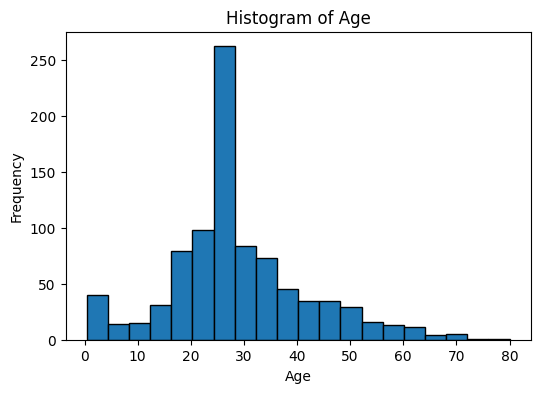

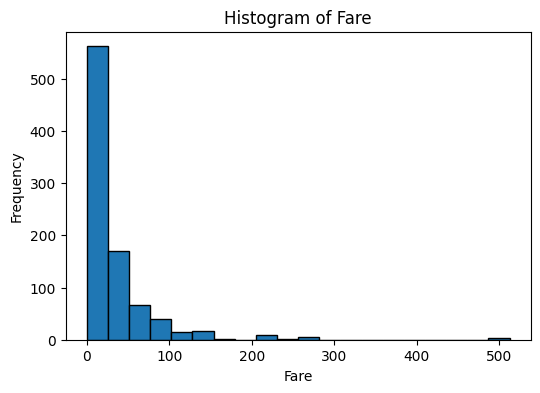

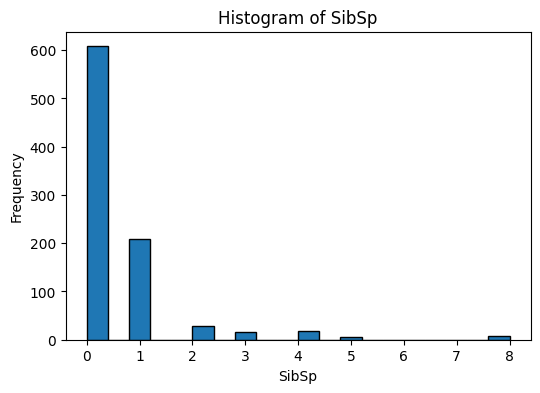

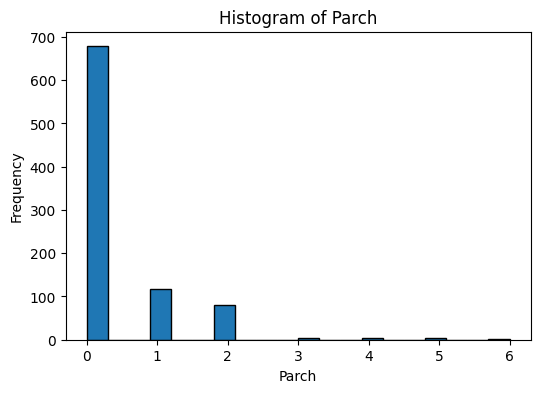

In [ ]:
numerical_columns = ["Age", "Fare", "SibSp", "Parch"]

for col in numerical_columns:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=20, edgecolor='black')
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

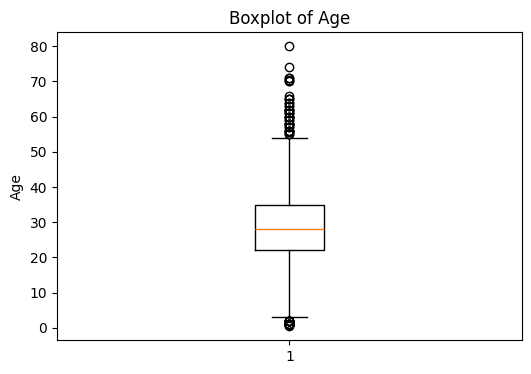

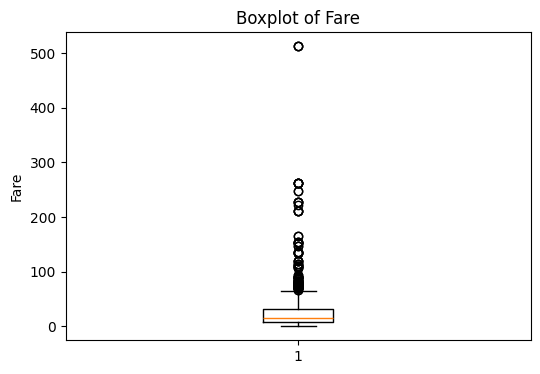

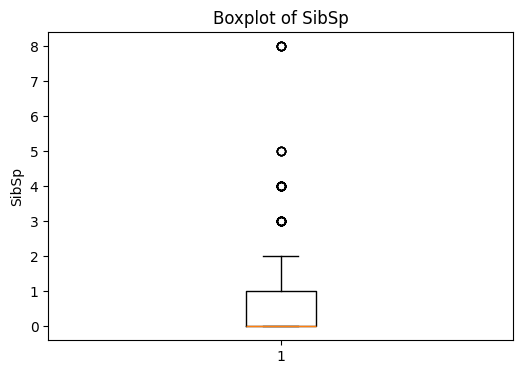

In [ ]:
box_columns = ["Age", "Fare", "SibSp"]

for col in box_columns:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

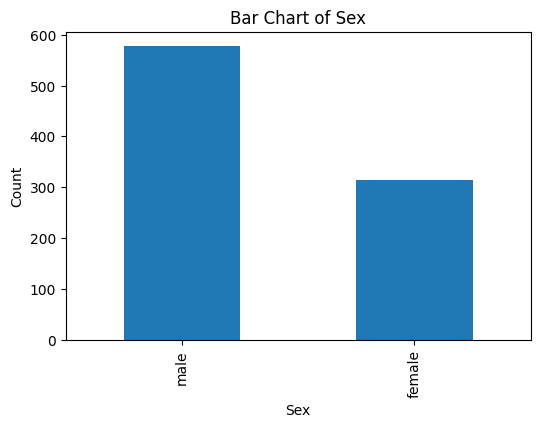

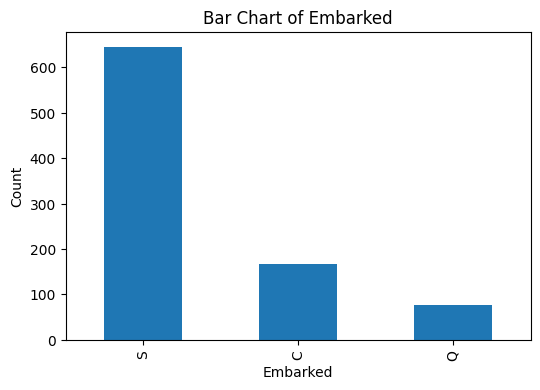

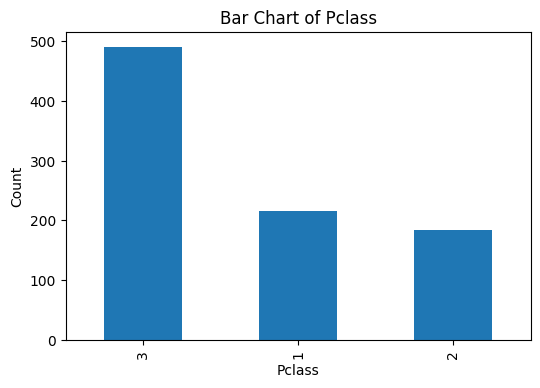

In [ ]:
categorical_columns = ["Sex", "Embarked", "Pclass"]

for col in categorical_columns:
    plt.figure(figsize=(6,4))
    df[col].value_counts().plot(kind="bar")
    plt.title(f"Bar Chart of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

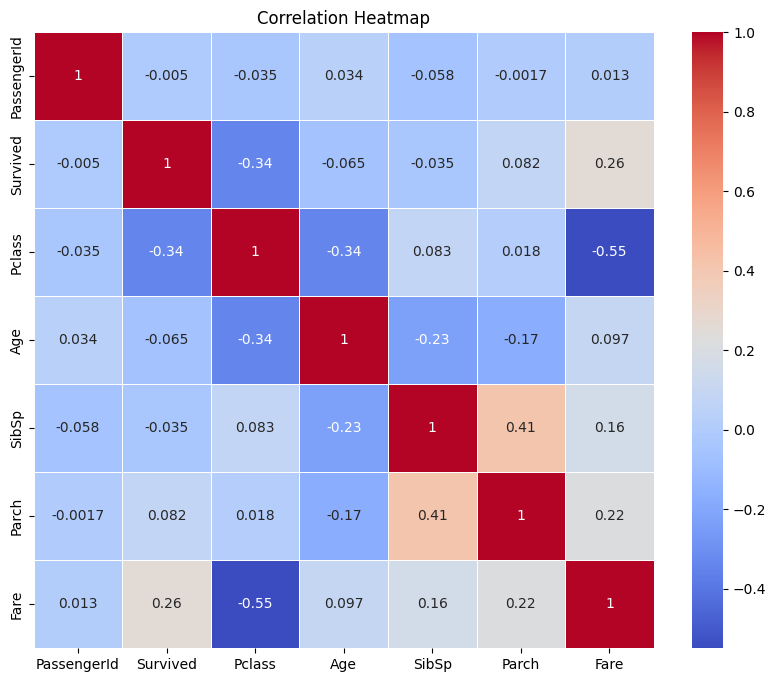

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

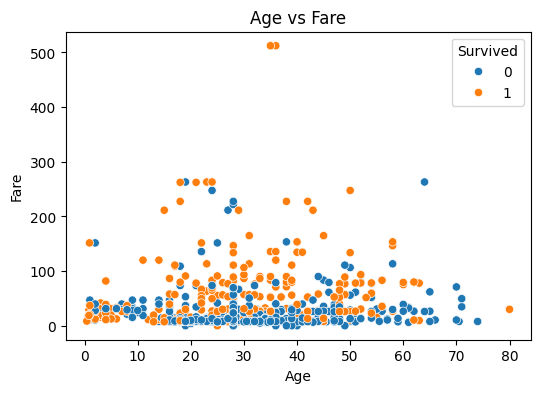

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df,x="Age",y="Fare",hue="Survived")
plt.title("Age vs Fare")
plt.show()

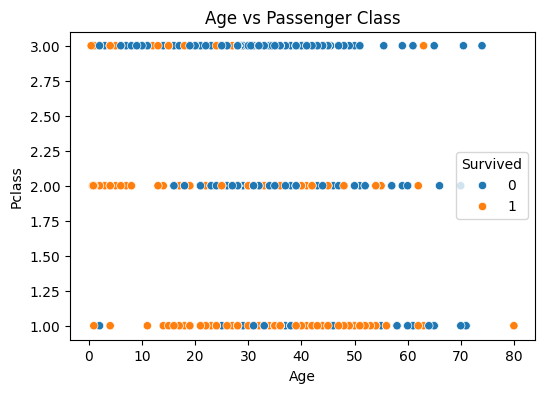

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df,x="Age",y="Pclass",hue="Survived")
plt.title("Age vs Passenger Class")
plt.show()

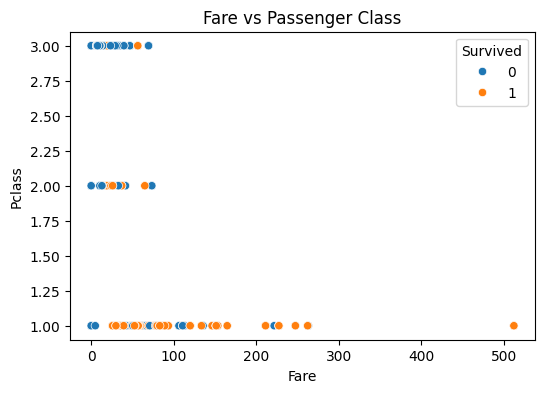

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df,x="Fare",y="Pclass",hue="Survived")
plt.title("Fare vs Passenger Class")
plt.show()

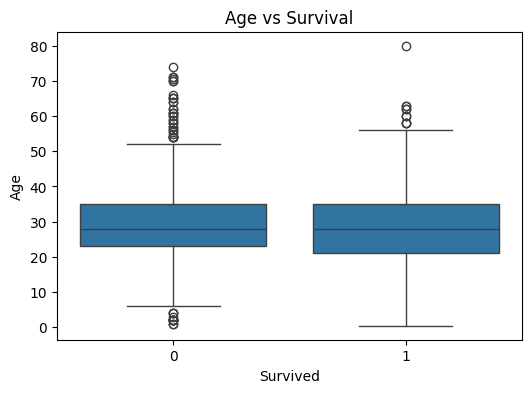

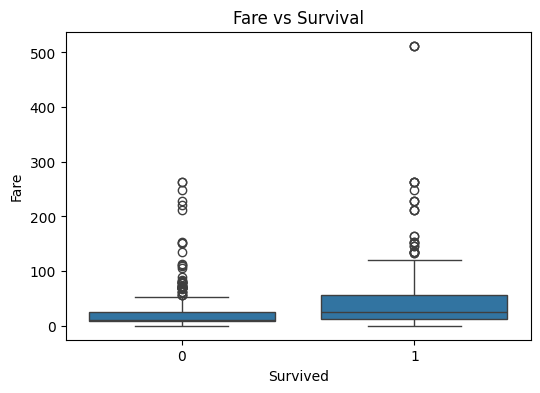

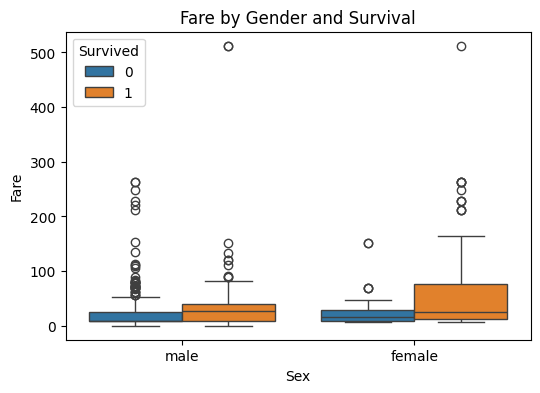

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df,x="Survived",y="Age")
plt.title("Age vs Survival")
plt.show()


plt.figure(figsize=(6,4))
sns.boxplot(data=df,x="Survived",y="Fare")
plt.title("Fare vs Survival")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(data=df,x="Sex",y="Fare",hue="Survived")
plt.title("Fare by Gender and Survival")
plt.show()

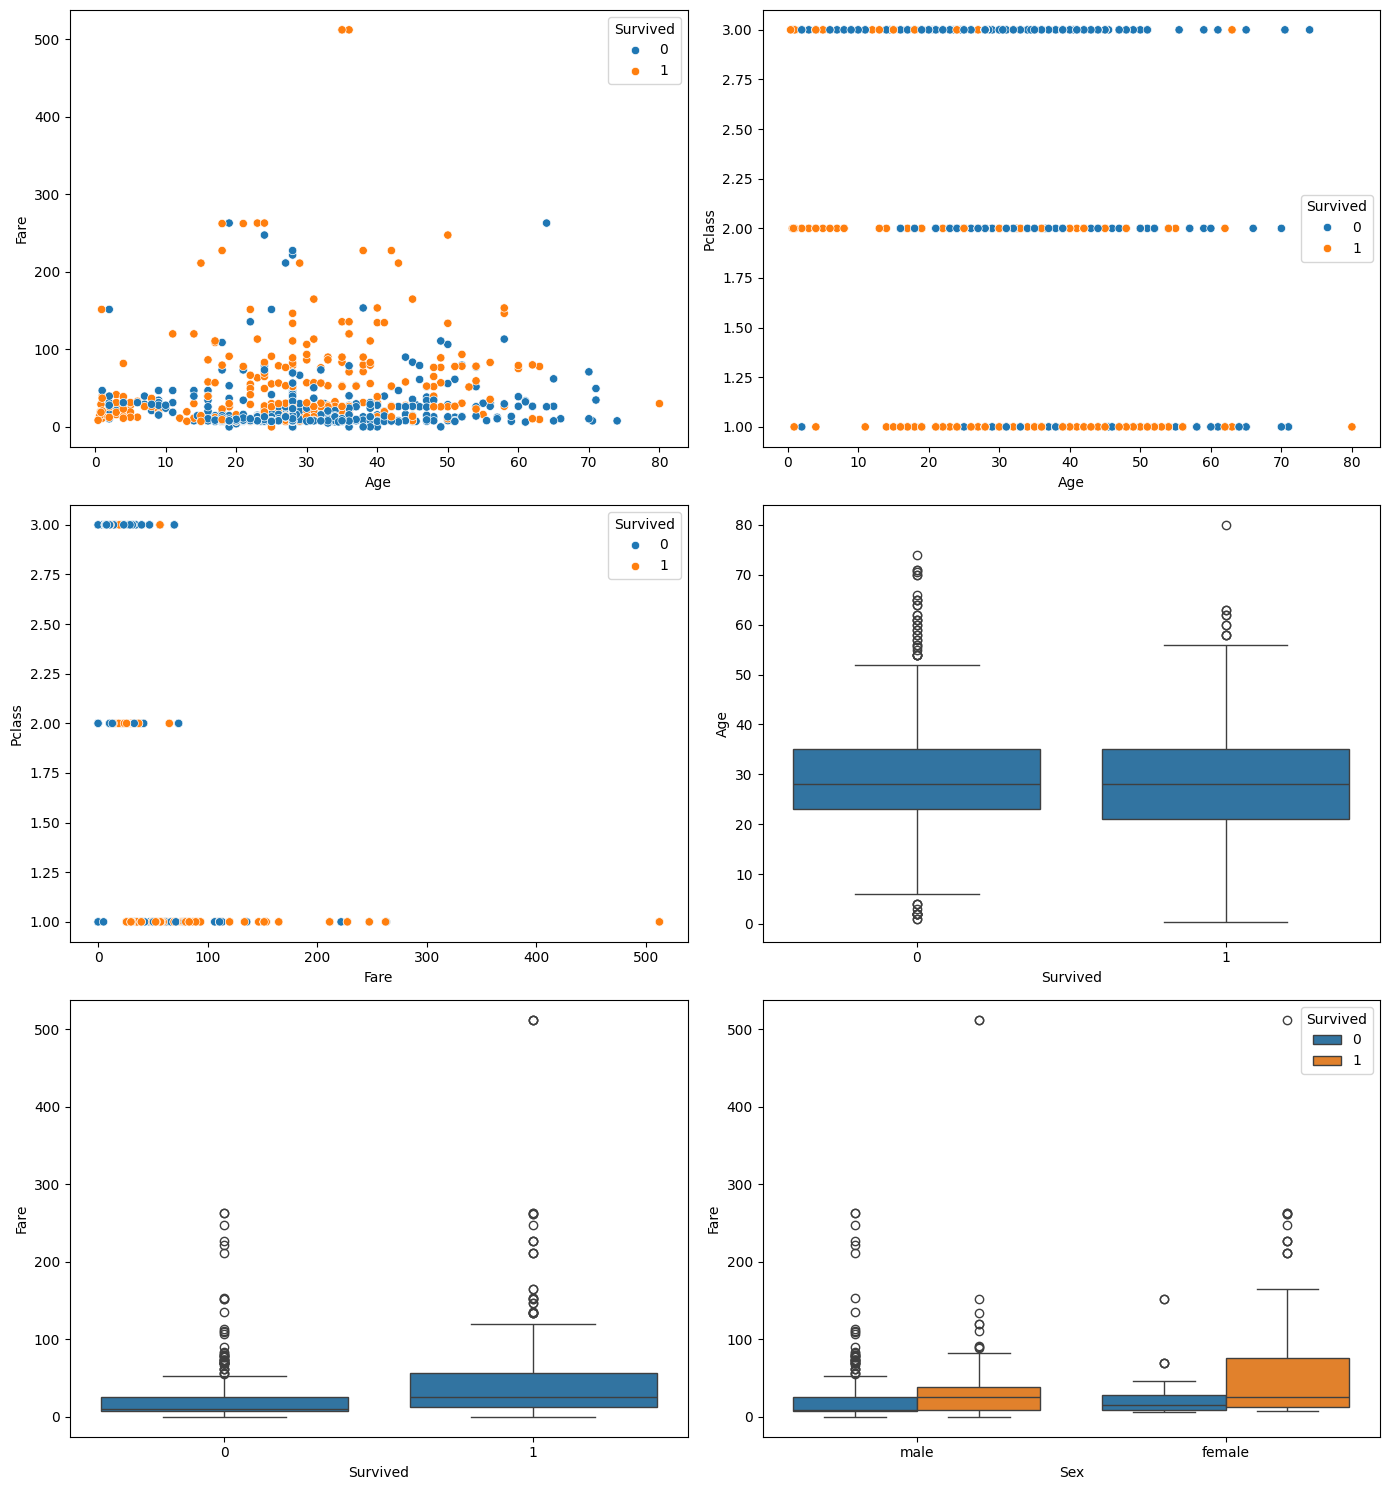

In [ ]:
fig, axes = plt.subplots(3,2,figsize=(14,15))

sns.scatterplot(data=df,x="Age",y="Fare",hue="Survived",ax=axes[0,0])

sns.scatterplot(data=df,x="Age",y="Pclass",hue="Survived",ax=axes[0,1])

sns.scatterplot(data=df,x="Fare",y="Pclass",hue="Survived",ax=axes[1,0])

sns.boxplot(data=df,x="Survived",y="Age",ax=axes[1,1])

sns.boxplot(data=df,x="Survived",y="Fare",ax=axes[2,0])

sns.boxplot(data=df,x="Sex",y="Fare",hue="Survived",ax=axes[2,1])

plt.tight_layout()

plt.show()

In [ ]:
correlation = df.corr(numeric_only=True)["Survived"]

correlation.sort_values(ascending=False)

,Survived
Survived,1.000000
Fare,0.257307
Parch,0.081629
PassengerId,-0.005007
SibSp,-0.035322
Age,-0.064910
Pclass,-0.338481


In [ ]:
df.groupby("Sex")["Survived"].mean()

,Survived
Sex,
female,0.742038
male,0.188908


In [ ]:
df.groupby("Pclass")["Survived"].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


In [ ]:
df.groupby("Survived")["Fare"].mean()

,Fare
Survived,
0,22.117887
1,48.395408


In [ ]:
df["Child"] = df["Age"] < 18

df.groupby("Child")["Survived"].mean()


,Survived
Child,
False,0.361183
True,0.539823


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

In [ ]:
df = pd.read_csv("gold/clean_data.csv")

In [ ]:
label = LabelEncoder()

df["Sex"] = label.fit_transform(df["Sex"])
df["Embarked"] = label.fit_transform(df["Embarked"])
df["Cabin"] = label.fit_transform(df["Cabin"])
df["Ticket"] = label.fit_transform(df["Ticket"])
df["Name"] = label.fit_transform(df["Name"])

In [ ]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.8212290502793296


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8379888268156425


In [ ]:
gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

gb_accuracy = accuracy_score(y_test, gb_pred)

print("Gradient Boosting Accuracy:", gb_accuracy)

Gradient Boosting Accuracy: 0.8100558659217877


In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        gb_accuracy
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.821229
1,Random Forest,0.837989
2,Gradient Boosting,0.810056


In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
3,Sex,0.240301
7,Ticket,0.146451
8,Fare,0.118409
2,Name,0.107532
4,Age,0.100183
0,PassengerId,0.099929
1,Pclass,0.058229
9,Cabin,0.055429
5,SibSp,0.029943
6,Parch,0.022035


<Figure size 800x600 with 0 Axes>

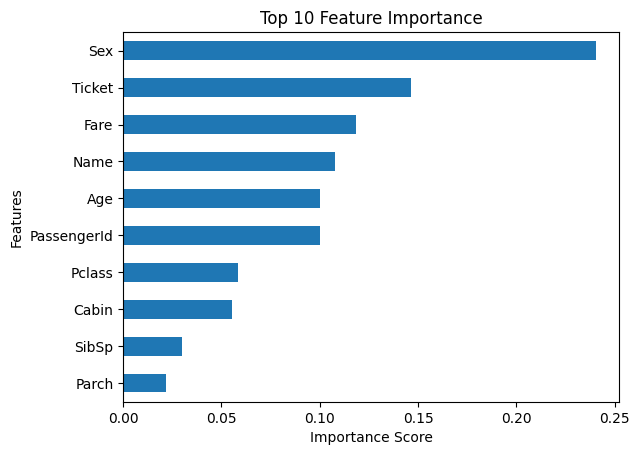

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

importance.head(10).sort_values(
    "Importance"
).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    legend=False
)

plt.title("Top 10 Feature Importance")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.show()

In [ ]:
importance[
    importance["Importance"] < 0.01
]

,Feature,Importance


In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=5000,
    solver="lbfgs"
)

In [ ]:
from sklearn.ensemble import StackingClassifier
stack = StackingClassifier(
    estimators=[
        ("lr", lr),
        ("rf", rf),
        ("gb", gb)
    ],
    final_estimator=LogisticRegression(max_iter=5000)
)

stack.fit(X_train, y_train)

stack_pred = stack.predict(X_test)

stack_accuracy = accuracy_score(
    y_test,
    stack_pred
)

print("Stacking Accuracy:", stack_accuracy)

Stacking Accuracy: 0.8268156424581006


In [ ]:
comparison.loc[len(comparison)] = [
    "Stacking Ensemble",
    stack_accuracy
]

comparison

,Model,Accuracy
0,Logistic Regression,0.821229
1,Random Forest,0.837989
2,Gradient Boosting,0.810056
3,Stacking Ensemble,0.826816


In [ ]:
!pip install shap

In [ ]:
import shap

explainer = shap.TreeExplainer(rf)

shap_values = explainer(X_test)

In [ ]:
import shap

print(shap.__version__)
print(type(shap_values))

0.52.0
<class 'shap._explanation.Explanation'>


In [ ]:
print(shap_values.shape)

(179, 11, 2)


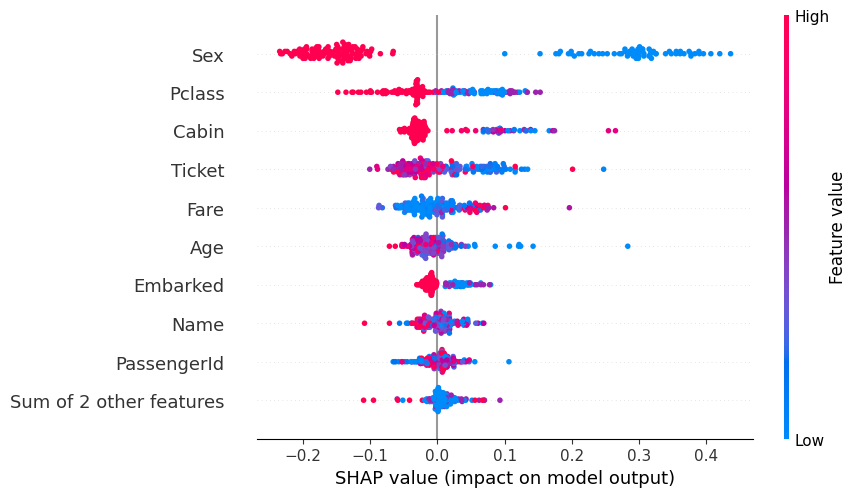

In [ ]:
shap.plots.beeswarm(shap_values[:, :, 1])

In [ ]:
shap.initjs()

shap.plots.force(shap_values[0, :, 1])

In [ ]:
print("Training Accuracy:",
      rf.score(X_train, y_train))

print("Testing Accuracy:",
      rf.score(X_test, y_test))

Training Accuracy: 1.0
Testing Accuracy: 0.8379888268156425


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5
)

print(scores)

print("Mean:", scores.mean())

print("Standard Deviation:",
      scores.std())

[0.80446927 0.83146067 0.87078652 0.84269663 0.85955056]
Mean: 0.8417927311530977
Standard Deviation: 0.023050332166718222


In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators":[100,200],
    "max_depth":[5,10],
    "min_samples_split":[2,5]
}

grid = GridSearchCV(
    rf,
    params,
    cv=5
)

grid.fit(X_train,y_train)

print(grid.best_params_)

{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


In [ ]:
# Predict using the final Random Forest model
predictions = rf.predict(X_test)

# Display Actual vs Predicted values
prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

prediction_df.head(10)

,Actual,Predicted
0,1,0
1,0,0
2,0,0
3,1,1
4,1,1
5,1,1
6,1,1
7,0,0
8,1,1
9,1,1


In [ ]:
# Predict the first passenger in the test set
sample = X_test.iloc[[0]]

prediction = rf.predict(sample)

print("Prediction:", prediction[0])

if prediction[0] == 1:
    print("Passenger is predicted to Survive.")
else:
    print("Passenger is predicted NOT to Survive.")

Prediction: 0
Passenger is predicted NOT to Survive.


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Final Model Accuracy:", accuracy)

Final Model Accuracy: 0.8379888268156425
